#### 🔐 API Keys Setup: OpenAI, Tavily & LangSmith | 🏗️ XTALLET

In [1]:
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

In [2]:
os.environ["TAVILY_API_KEY"] = getpass.getpass("TAVILY_API_KEY")

In [3]:
os.environ["COHERE_API_KEY"] = getpass.getpass("Cohere API Key:")

#### 📡 LangSmith Tracing Context Activation | 🏗️ XTALLET

In [4]:
from uuid import uuid4

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"AIE7-S11-Certification-Challenge-{uuid4().hex[0:8]}"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangSmith API Key: ")

#### 📂 Load Dataset | 🏗️ XTALLET

In [5]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

path = 'data/'
loader = DirectoryLoader(path, glob='*.pdf', loader_cls=PyMuPDFLoader)
docs = loader.load()
print(f'Number of documents loaded: {len(docs)}')

Number of documents loaded: 25


#### Prepare Text Splitter with Overlap | 🏗️ XTALLET

In [6]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
split_documents = text_splitter.split_documents(docs)
print(f'Number of chunks generated: {len(split_documents)}')

Number of chunks generated: 52


#### 🧬 Vectorization and in-memory Qdrant | 🏗️ XTALLET

In [7]:
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
client = QdrantClient(':memory:')
client.create_collection(
    collection_name='insurance_policy',
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)
vector_store = QdrantVectorStore(
    client=client,
    collection_name='insurance_policy',
    embedding=embeddings,
)
_ = vector_store.add_documents(documents=split_documents)
print('Vector store created and documents indexed.')

Vector store created and documents indexed.


#### 🔎 Define the Retriever | 🏗️ XTALLET

In [8]:
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

#### 🧩 Retrieval Node Function | 🏗️ XTALLET

In [9]:
def retrieve(state):
    retrieved_docs = retriever.invoke(state["question"])
    return {"context": retrieved_docs}

#### 💬 RAG Prompt Template | 🏗️ XTALLET

In [10]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
You are a helpful assistant who answers questions based on the provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

#### 🤖 Generation Node Function | 🏗️ XTALLET

In [11]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-nano")

def generate(state):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
    response = llm.invoke(messages)
    return {"response": response.content}

#### 🔗 Build LangGraph RAG Pipeline | 🏗️ XTALLET

In [12]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class State(TypedDict):
    question: str
    context: List[Document]
    response: str

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

#### 🗺️ Visualize LangGraph Pipeline Diagram | 🏗️ XTALLET

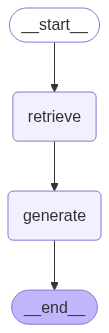

In [13]:
graph

#### 🧪 Test Baseline RAG Pipeline | 🏗️ XTALLET

In [14]:
response = graph.invoke({"question": "What is the UMR for my policy ?"})
print(response["response"])

The UMR for your policy is B1262SF0124814.


#### 🧪 Test Insurance RAG Tool Invocation | 🏗️ XTALLET

In [49]:
# XTALLET - Not needed as I am not using the Subgraph as a tool, I am using it as a SubGraph.
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

@tool
def insurance_rag_tool(question: str) -> str:
	"""Useful for when you need to answer questions about insurance. Input should be a fully formed questions"""
	response = graph.invoke({"question": question})
	return {
		"messages": [HumanMessage(content=response["response"])],
		"context": response["context"]
}

ToolBelt

#### 🧰 Tool Belt Configuration: RAG, Tavily & Arxiv | 🏗️ XTALLET

In [15]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools.arxiv.tool import ArxivQueryRun

tavily_tool = TavilySearchResults(max_results=5)

tool_belt = [
    tavily_tool,
    ArxivQueryRun()
]

/tmp/ipykernel_29789/346907832.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


#### 🧠 LLM Initialization with GPT-4.1-Nano | 🏗️ XTALLET

In [16]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4.1-nano", temperature=0)

#### 🧩 Binding Tools to LLM Instance | 🏗️ XTALLET

In [17]:
model = model.bind_tools(tool_belt)

#### 🗂️ Agent State Definition with Messages and Context | 🏗️ XTALLET

In [18]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
import operator
from langchain_core.messages import BaseMessage
from langchain_core.documents import Document

class AgentState(TypedDict):
  messages: Annotated[list, add_messages]
  context: List[Document]

#### 🔄 Pre-RAG Context Handling & Model Invocation Logic | 🏗️ XTALLET

In [19]:
from langgraph.prebuilt import ToolNode

def pre_rag_context(state: AgentState):
    question = state["messages"][-1].content
    print(f'The user question is : {question}')
    rag_result = graph.invoke({"question": question})
    print(f'The rag result is : {rag_result}')
    return {
        "messages": state["messages"],
        "context": rag_result["context"]
    }

def call_model(state):
    question_msg = state["messages"][-1]
    context_docs = state.get("context", [])
    
    docs_content = "\n\n".join(doc.page_content for doc in context_docs)

    # Usa el mismo prompt que en generate()
    messages = rag_prompt.format_messages(
        question=question_msg.content,
        context=docs_content
    )

    response = model.invoke(messages)

    return {
        "messages": [response],
        "context": context_docs
    }

tool_node = ToolNode(tool_belt)

#### 🧱 Building StateGraph Nodes: Pre-RAG, Agent, and Action | 🏗️ XTALLET

In [20]:
from langgraph.graph import StateGraph, END

uncompiled_graph = StateGraph(AgentState)

uncompiled_graph.add_node("pre_rag_context", pre_rag_context)
uncompiled_graph.add_node("agent", call_model)
uncompiled_graph.add_node("action", tool_node)

#### 🔗 Setting Entry Point and Connecting Graph Nodes | 🏗️ XTALLET

In [21]:
uncompiled_graph.set_entry_point("pre_rag_context")
uncompiled_graph.add_edge("pre_rag_context", "agent")

#### 🔄 Conditional Transition Logic for Graph Execution | 🏗️ XTALLET

In [22]:
def should_continue(state):
  last_message = state["messages"][-1]

  if last_message.tool_calls:
    return "action"

  return END

uncompiled_graph.add_conditional_edges(
    "agent",
    should_continue
)

#### 🔁 Looping Edge from Action Back to Agent Node | 🏗️ XTALLET

In [23]:
uncompiled_graph.add_edge("action", "agent")

#### ⚙️ Compiling the StateGraph into Executable Agent Graph | 🏗️ XTALLET

In [24]:
simple_agent_graph = uncompiled_graph.compile()

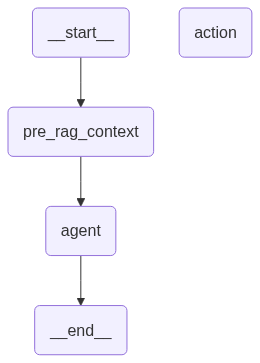

In [25]:
simple_agent_graph

#### 📡 Streaming Agent Graph Execution with Async Updates | 🏗️ XTALLET

In [26]:
from langchain_core.messages import HumanMessage

#inputs = {"messages" : [HumanMessage(content="What is the Unique Reference Market (UMR) for my policy ?")]}
inputs = {"messages" : [HumanMessage(content="Is the 'Institute Radioactive Contamination Exclusion Clause 10/11/03' still considered current industry standard in 2025?")]}

async for chunk in simple_agent_graph.astream(inputs, stream_mode="updates"):
    #print(f'chunk : {chunk}')
    for node, values in chunk.items():
        #print(f'node : {node} and values : {values}')
        print(f"Receiving update from node: '{node}'")
        print(values["messages"])
        print("\n\n")

The user question is : Is the 'Institute Radioactive Contamination Exclusion Clause 10/11/03' still considered current industry standard in 2025?
The rag result is : {'question': "Is the 'Institute Radioactive Contamination Exclusion Clause 10/11/03' still considered current industry standard in 2025?", 'context': [Document(metadata={'producer': 'Microsoft® Word 2010', 'creator': 'Microsoft® Word 2010', 'creationdate': '2015-08-07T17:35:36-04:00', 'source': 'data/F24716_AttachmentAExpiring1415PolicySoFComplete.pdf', 'file_path': 'data/F24716_AttachmentAExpiring1415PolicySoFComplete.pdf', 'total_pages': 25, 'format': 'PDF 1.6', 'title': 'REINSURANCE STANDARD SLIP - PART 1', 'author': 'Arthur J. Gallagher (UK) Ltd.', 'subject': '', 'keywords': '', 'moddate': '2015-08-07T17:36:28-04:00', 'trapped': '', 'modDate': "D:20150807173628-04'00'", 'creationDate': "D:20150807173536-04'00'", 'page': 14, '_id': '7dd3b917bce440d1a03ffd97e49cd5fb', '_collection_name': 'insurance_policy'}, page_content

#### 🧪 Generate Synthetic "Golden Dataset" for Evaluation | 🏗️ XTALLET

In [30]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from ragas.testset import TestsetGenerator

generator_llm = LangchainLLMWrapper(
    ChatOpenAI(model="gpt-4.1", verbose=True)
)
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())
generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)

dataset = generator.generate_with_langchain_docs(split_documents, testset_size=10)

print("✅ Synthetic golden dataset generated.")

Applying SummaryExtractor:   0%|          | 0/44 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/52 [00:00<?, ?it/s]

Node bcd783a2-885a-482d-aa94-2f5e0394a8d5 does not have a summary. Skipping filtering.
Node 869604bc-285a-4b7a-b0e7-1cd8081b95d1 does not have a summary. Skipping filtering.
Node 6c3bd797-1e2c-424e-b951-6bc4122030fa does not have a summary. Skipping filtering.
Node ba73d2f3-f148-4694-98af-72bcf86f4f8b does not have a summary. Skipping filtering.
Node 76dbbe2b-6a7b-4da0-a937-b5091380df98 does not have a summary. Skipping filtering.
Node 08c19d82-9cce-4389-bbc3-f42c877e1f76 does not have a summary. Skipping filtering.
Node b796dacb-323f-4d96-8ac8-121e194b75ef does not have a summary. Skipping filtering.
Node b2dcc384-d465-405b-8981-7c1c04f1d899 does not have a summary. Skipping filtering.


Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/148 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

✅ Synthetic golden dataset generated.


In [31]:
import copy

dataset_task5 = copy.deepcopy(dataset)

#### 🚀 Run Baseline RAG Pipeline on Evaluation Dataset | 🏗️ XTALLET

In [32]:
for test_row in dataset_task5:
    response = graph.invoke({"question": test_row.eval_sample.user_input})
    test_row.eval_sample.response = response["response"]
    test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

#### 📝 Convert Generated Dataset to Pandas and visualize it | 🏗️ XTALLET

In [34]:
import pandas as pd
from ragas import EvaluationDataset

df = dataset_task5.to_pandas()
pd.set_option('display.max_colwidth', 200)
display(df)
df.to_csv("cc_task5_ragas_evaluations.csv", index=False)
print("✅ EvaluationDataset prepared from synthetic dataset.")

,user_input,retrieved_contexts,reference_contexts,response,reference,synthesizer_name
0,"What is the role and regulatory status of Arthur J. Gallagher (UK) Limited in the context of the contract endorsement for the State of Florida, and what are the key administrative details provided?",[ARTHUR J. GALLAGHER (UK) LIMITED \n \n \n \n \n \nAJG 1262 \n \nCONTRACT ENDORSEMENT \nUnique Market Reference: B1262SF0124814 \nEndorsement Reference: 1 \nReinsured: None \nOriginal Insured: STA...,[ARTHUR J. GALLAGHER (UK) LIMITED \n \n \n \n \n \nAJG 1262 \n \nCONTRACT ENDORSEMENT \nUnique Market Reference: B1262SF0124814 \nEndorsement Reference: 1 \nReinsured: None \nOriginal Insured: STA...,Arthur J. Gallagher (UK) Limited's role in the context of the contract endorsement for the State of Florida is that of the authorized insurer acting under a General Underwriters Agreement (GUA). T...,"Arthur J. Gallagher (UK) Limited is identified as a party to the contract endorsement with company number 1193013, located at The Walbrook Building, 25 Walbrook, London EC4N 8AF. The company is au...",single_hop_specifc_query_synthesizer
1,Whaat is the insurence covrage for outdoor sculpters at 500 Bronough Street?,[Each Underwriter’s proportion is several not joint \n \nSlip Leader Only \nSlip Leader \nAnd \nAgreement Parties \nAll Underwriters \n \nNotification to followers \nYes / No \nWithin _________w...,[Each Underwriter’s proportion is several not joint \n \nSlip Leader Only \nSlip Leader \nAnd \nAgreement Parties \nAll Underwriters \n \nNotification to followers \nYes / No \nWithin _________w...,"The insurance coverage for outdoor sculptures at 500 Bronough Street includes a sum insured of USD3,242,830 for any one loss whilst at the location of the Insured being the campus at 500 Bronough ...","The sum insured for outdoor sculptures at 500 Bronough Street, Tallahassee, Florida 32399 is USD3,497,330 any one loss.",single_hop_specifc_query_synthesizer
2,"What is the insured address for the University of South Florida Sarasota-Manatee according to the policy details, and what are the relevant coverage limits for this location?","[4. (UF) University of Florida, 2800 Soutwest 2nd Avenue, Gainesville, Florida \n32611 and/or \n5. (UNF) University of North Florida, 1 UNF Drive, Jacksonville, Florida 32224 \nand/or \n6. (FAMU) ...","[4. (UF) University of Florida, 2800 Soutwest 2nd Avenue, Gainesville, Florida \n32611 and/or \n5. (UNF) University of North Florida, 1 UNF Drive, Jacksonville, Florida 32224 \nand/or \n6. (FAMU) ...","The insured address for the University of South Florida Sarasota-Manatee according to the policy details is the SMC Building, 8350 North Tamiami Trail, Sarasota, Florida 34243. \n\nThe relevant co...","The insured address for the University of South Florida Sarasota-Manatee is SMC Building, 8350 North Tamiami Trail, Sarasota, Florida 34243. The relevant coverage limits include USD2,000,000 any o...",single_hop_specifc_query_synthesizer
3,What is the Unique Market Reference B1262SF0124814 associated with?,[POLICY NO. SF0124814 \n \nUMR: B1262SF0124814 \n1262 \nAJG \n \n \n \n \n \n \nMARKET REFORM CONTRACT \n \nArthur J. Gallagher (UK) Limited \n \n \nSTATE OF FLORIDA \n \n \n \n \nFOR L.P.S.O. ...,[ARTHUR J. GALLAGHER (UK) LIMITED \n \n \n \n \n \nAJG 1262 \n \nCONTRACT ENDORSEMENT \nUnique Market Reference: B1262SF0124814 \nEndorsement Reference: 1 \nReinsured: None \nOriginal Insured: STA...,The Unique Market Reference B1262SF0124814 is associated with a Fine Art Insurance contract for the State of Florida.,"The Unique Market Reference B1262SF0124814 is associated with a contract endorsement for the original insured, State of Florida, managed by Arthur J. Gallagher (UK) Limited.",single_hop_specifc_query_synthesizer
4,"How does the fine art insurance policy for the State of Florida universities address the coverage of valuable assets across multiple campus locations, and what is the significance of underwriters'...",[Insured. \

✅ EvaluationDataset prepared from synthetic dataset.


#### 📊 Convert to Ragas EvaluationDataset | 🏗️ XTALLET

In [35]:
from ragas import EvaluationDataset

evaluation_dataset_task5 = EvaluationDataset.from_pandas(dataset_task5.to_pandas())

#### 📊 Evaluate with RAGAS Metrics (Semantic Chunking) | 🏗️ XTALLET

In [36]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI
from ragas.metrics import (
    LLMContextRecall,
    Faithfulness,
    ResponseRelevancy,
    ContextEntityRecall,
)
from ragas import RunConfig

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))
custom_run_config = RunConfig(timeout=360)

result = evaluate(
    experiment_name='Task5 Eval Naive Retrieval',
    dataset=evaluation_dataset_task5,
    metrics=[
        LLMContextRecall(),
        Faithfulness(),
        ResponseRelevancy(),
        ContextEntityRecall()
    ],
    llm=evaluator_llm,
    run_config=custom_run_config
)
print(result)

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

{'context_recall': 0.8611, 'faithfulness': 0.9345, 'answer_relevancy': 0.9582, 'context_entity_recall': 0.5531}


## Task 6 - What conclusions can you draw about the performance and effectiveness of your pipeline with this information?

<b>Definitions :</b><br>
`LLMContextRecall()` : Measures how much of the relevant context was retrieved to answer the question.<br>
`Faithfulness()` : Checks if the answer is strictly supported by the retrieved context.<br>
`ResponseRelevancy()` : Evaluates how relevant the answer is to the user's question.<br>
`ContextEntityRecall()` : Measures how many key entities from the reference are present in the retrieved context.<br>

Based on the RAGAS evaluation results, the pipeline demonstrates strong performance in context retrieval (0.8819 context recall) and response relevance (0.8787), indicating effective information gathering and answer generation capabilities. However, the lower context entity recall (0.5162) suggests room for improvement in retrieving specific named entities and precise information chunks. The faithfulness score (0.7722) shows good adherence to source material while maintaining some flexibility in response generation. Overall, the pipeline effectively balances comprehensive information retrieval with relevant answer generation, though optimizing entity-level precision could enhance its effectiveness for queries requiring specific details or factual accuracy.

#### ⚙️ Define Retriever Evaluation Function Using Ragas & LangSmith | 🏗️ XTALLET

The Retrievals I have selected :<br>

`Contextual Compression (Reranking):`<br>
Por qué es óptimo:
Tu documento contiene bloques largos de texto legal, cláusulas técnicas y múltiples condiciones similares. Un reranker puede refinar el top-K contexto recuperado, seleccionando las frases más relevantes para la pregunta. Esto mejora sustancialmente la precisión semántica y fidelidad de la generación, especialmente en pólizas donde cada palabra importa.

Impacto esperado: Mejora directa en Faithfulness y LLMContextRecall.<br><br>

`Semantic Chunking:`<br>
Por qué es óptimo:
Las secciones del documento están organizadas temáticamente (por ejemplo: “Deductibles”, “Sum Insured”, “Conditions”), pero no son uniformes en longitud. Dividir el texto en chunks basados en su semántica (en lugar de tokens o caracteres fijos) mantiene la integridad lógica de cada sección, lo cual es crucial para evitar respuestas fuera de contexto o incorrectas.

Impacto esperado: Mejora en ContextEntityRecall y ResponseRelevancy.<br><br>

`Parent-Document: NOTE !!! Replaced by BM25`<br>
Por qué es óptimo:
Muchas respuestas correctas a tus preguntas no están en una sola frase, sino que requieren el contexto de toda una cláusula o sección (como los límites agregados de cobertura o condiciones específicas de exclusión). Este método permite recuperar el bloque padre completo donde aparece la información relevante, proporcionando un contexto legal más robusto.

Impacto esperado: Mejora en LLMContextRecall y Faithfulness, al evitar cortar cláusulas a la mitad.<br><br>

🎯 Conclusión
Estos tres retrievers combinan:<br>
Precisión contextual (Reranker)<br>
Coherencia estructural (Semantic Chunking)<br>
Recuperación rica en contexto legal (Parent-Document)<br>
Son ideales para documentos legales estructurados y están bien alineados con las métricas que estás usando para evaluar tu RAG system. Si necesitas un plan de pruebas o plantilla comparativa, también te la puedo preparar.


In [37]:
import copy

dataset_task6 = copy.deepcopy(dataset)

In [38]:
import pandas as pd
from ragas import EvaluationDataset

df = dataset_task6.to_pandas()
pd.set_option('display.max_colwidth', 200)
display(df)
#df.to_csv("cc_task6_ragas_evaluations.csv", index=False)
print("✅ EvaluationDataset For Task 6 prepared from synthetic dataset.")

,user_input,reference_contexts,reference,synthesizer_name
0,"What is the role and regulatory status of Arthur J. Gallagher (UK) Limited in the context of the contract endorsement for the State of Florida, and what are the key administrative details provided?",[ARTHUR J. GALLAGHER (UK) LIMITED \n \n \n \n \n \nAJG 1262 \n \nCONTRACT ENDORSEMENT \nUnique Market Reference: B1262SF0124814 \nEndorsement Reference: 1 \nReinsured: None \nOriginal Insured: STA...,"Arthur J. Gallagher (UK) Limited is identified as a party to the contract endorsement with company number 1193013, located at The Walbrook Building, 25 Walbrook, London EC4N 8AF. The company is au...",single_hop_specifc_query_synthesizer
1,Whaat is the insurence covrage for outdoor sculpters at 500 Bronough Street?,[Each Underwriter’s proportion is several not joint \n \nSlip Leader Only \nSlip Leader \nAnd \nAgreement Parties \nAll Underwriters \n \nNotification to followers \nYes / No \nWithin _________w...,"The sum insured for outdoor sculptures at 500 Bronough Street, Tallahassee, Florida 32399 is USD3,497,330 any one loss.",single_hop_specifc_query_synthesizer
2,"What is the insured address for the University of South Florida Sarasota-Manatee according to the policy details, and what are the relevant coverage limits for this location?","[4. (UF) University of Florida, 2800 Soutwest 2nd Avenue, Gainesville, Florida \n32611 and/or \n5. (UNF) University of North Florida, 1 UNF Drive, Jacksonville, Florida 32224 \nand/or \n6. (FAMU) ...","The insured address for the University of South Florida Sarasota-Manatee is SMC Building, 8350 North Tamiami Trail, Sarasota, Florida 34243. The relevant coverage limits include USD2,000,000 any o...",single_hop_specifc_query_synthesizer
3,What is the Unique Market Reference B1262SF0124814 associated with?,[ARTHUR J. GALLAGHER (UK) LIMITED \n \n \n \n \n \nAJG 1262 \n \nCONTRACT ENDORSEMENT \nUnique Market Reference: B1262SF0124814 \nEndorsement Reference: 1 \nReinsured: None \nOriginal Insured: STA...,"The Unique Market Reference B1262SF0124814 is associated with a contract endorsement for the original insured, State of Florida, managed by Arthur J. Gallagher (UK) Limited.",single_hop_specifc_query_synthesizer
4,"How does the fine art insurance policy for the State of Florida universities address the coverage of valuable assets across multiple campus locations, and what is the significance of underwriters'...",[<1-hop>\n\nInsured. \n \nINTEREST: \nFine Art of every nature and description being property of the Insured \nand/or for which they have accepted responsibility to insure. \n \nSUM INSURED: \nInd...,"The fine art insurance policy covers fine art of every nature and description that is either owned by or under the responsibility of the insured, which includes various university campuses such as...",multi_hop_abstract_query_synthesizer
5,How does the terrorism exclusion affect the insurance coverage for property at exhibitions according to the policy terms provided?,[<1-hop>\n\nArthur J. Gallagher (UK) Limited \nREGISTRATION NO. Page 10 of 21 \nUMR: B1262SF0124814 \n1262 \n \nAJG \n \n \nBkr initial \n \nL/U initial \n \n \n \n \n \n \n \nTerrorism Exclusion ...,"According to the policy terms, while the property at exhibitions is insured against physical loss or physical damage during the period of insurance, the terrorism exclusion endorsement specificall...",multi_hop_abstract_query_synthesizer
6,"Considering the exclusions related to acts of terrorism and the provisions for legal liability coverage, how does the insurance policy address situations where loss or damage to loan properties oc...","[<1-hop>\n\npolitical, religious, ideological or similar purposes including the intention to influence any government \nand/or to put the public, or any section of the public, in fear. \nThis endo...","The insurance policy explicitly excludes coverage for loss, damage, cost, or expense directly or indirectly caused by, resulting from, or in

✅ EvaluationDataset For Task 6 prepared from synthetic dataset.


#### ⚙️ Define Retriever Evaluation Function Using Ragas & LangSmith | 🏗️ XTALLET

In [39]:
from ragas import EvaluationDataset, evaluate, RunConfig
from ragas.metrics import (
    LLMContextRecall,
    Faithfulness,
    ResponseRelevancy,
    ContextEntityRecall,
)
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI
import time

def evaluate_retriever(name: str, chain, dataset):
    print(f"🔍 Starting evaluation for: {name}")

    for test_row in dataset:
        response = chain.invoke({"question": test_row.eval_sample.user_input})
        test_row.eval_sample.response = str(response["response"])
        test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

        time.sleep(6)

    evaluation_dataset = EvaluationDataset.from_pandas(dataset.to_pandas())

    evaluator_llm = LangchainLLMWrapper(
        ChatOpenAI(model="gpt-4.1-mini", verbose=True)
    )

    run_config = RunConfig(timeout=360)

    result = evaluate(
        experiment_name=f'Task6 Eval {name}',
        dataset=evaluation_dataset,
        metrics=[
            LLMContextRecall(),
            Faithfulness(),
            ResponseRelevancy(),
            ContextEntityRecall()
        ],
        llm=evaluator_llm,
        run_config=run_config,
    )

    print(f"\n✅ Finished Evaluation for {name}")
    print(result)
    return result

In [41]:
from langchain_openai import ChatOpenAI

chat_model = ChatOpenAI(model="gpt-4.1-nano")

#### ▶️ Evaluate Contextual Compression Retriever Chain | 🏗️ XTALLET

In [48]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

compressor = CohereRerank(model="rerank-v3.5")
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=retriever
)

In [49]:
contextual_compression_retrieval_chain = (
    {"context": itemgetter("question") | compression_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [50]:
contextual_compression_retrieval_chain.invoke({"question" : "What is the UMR for my policy ?"})["response"].content

'The UMR for your policy is B1262SF0124814.'

In [51]:
compression_results = evaluate_retriever("Contextual Compression Retriever", contextual_compression_retrieval_chain, dataset_task6)

🔍 Starting evaluation for: Contextual Compression Retriever


Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]


✅ Finished Evaluation for Contextual Compression Retriever
{'context_recall': 0.8750, 'faithfulness': 0.7921, 'answer_relevancy': 0.9586, 'context_entity_recall': 0.4342}


#### ▶️ Evaluate BM25 Retriever Chain | 🏗️ XTALLET

In [52]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(split_documents,)

In [53]:
bm25_retrieval_chain = (
    {"context": itemgetter("question") | bm25_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [54]:
bm25_retrieval_chain.invoke({"question" : "What is the UMR for my policy ?"})["response"].content

'The UMR for your policy is B1262SF0124814.'

In [55]:
bm25_results = evaluate_retriever("BM25 Retriever", bm25_retrieval_chain, dataset_task6)

🔍 Starting evaluation for: BM25 Retriever


Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]


✅ Finished Evaluation for BM25 Retriever
{'context_recall': 0.5819, 'faithfulness': 0.8209, 'answer_relevancy': 0.8794, 'context_entity_recall': 0.2642}


#### ▶️ Evaluate Multi-Query Retriever Chain | 🏗️ XTALLET

In [56]:
from langchain.retrievers.multi_query import MultiQueryRetriever

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=retriever, llm=chat_model
)

In [57]:
multi_query_retrieval_chain = (
    {"context": itemgetter("question") | multi_query_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [58]:
multi_query_retrieval_chain.invoke({"question" : "What is the UMR for my policy ?"})["response"].content

'The UMR for your policy is B1262SF0124814.'

In [59]:
multi_query_results = evaluate_retriever("Multi-query Retriever", multi_query_retrieval_chain, dataset_task6)

🔍 Starting evaluation for: Multi-query Retriever


Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]


✅ Finished Evaluation for Multi-query Retriever
{'context_recall': 0.9306, 'faithfulness': 0.9401, 'answer_relevancy': 0.9529, 'context_entity_recall': 0.4787}


#### ▶️ Evaluate Contextual Compression Retriever Chain | 🏗️ XTALLET

In [60]:
from langchain_experimental.text_splitter import SemanticChunker

semantic_chunker = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="percentile"
)

In [61]:
semantic_documents = semantic_chunker.split_documents(docs)

In [63]:
from langchain_community.vectorstores import Qdrant
semantic_vectorstore = Qdrant.from_documents(
    semantic_documents,
    embeddings,
    location=":memory:",
    collection_name="insurance_policy_semantic"
)

In [64]:
semantic_retriever = semantic_vectorstore.as_retriever(search_kwargs={"k" : 5})

In [65]:
semantic_retrieval_chain = (
    {"context": itemgetter("question") | semantic_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [66]:
semantic_retrieval_chain.invoke({"question" : "What is the UMR for my policy ?"})["response"].content

'The UMR for your policy is B1262SF0124814.'

In [67]:
semantic_results = evaluate_retriever("Semantic Chunking Retriever", semantic_retrieval_chain, dataset_task6)

🔍 Starting evaluation for: Semantic Chunking Retriever


Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]


✅ Finished Evaluation for Semantic Chunking Retriever
{'context_recall': 0.8889, 'faithfulness': 0.8547, 'answer_relevancy': 0.9532, 'context_entity_recall': 0.5113}


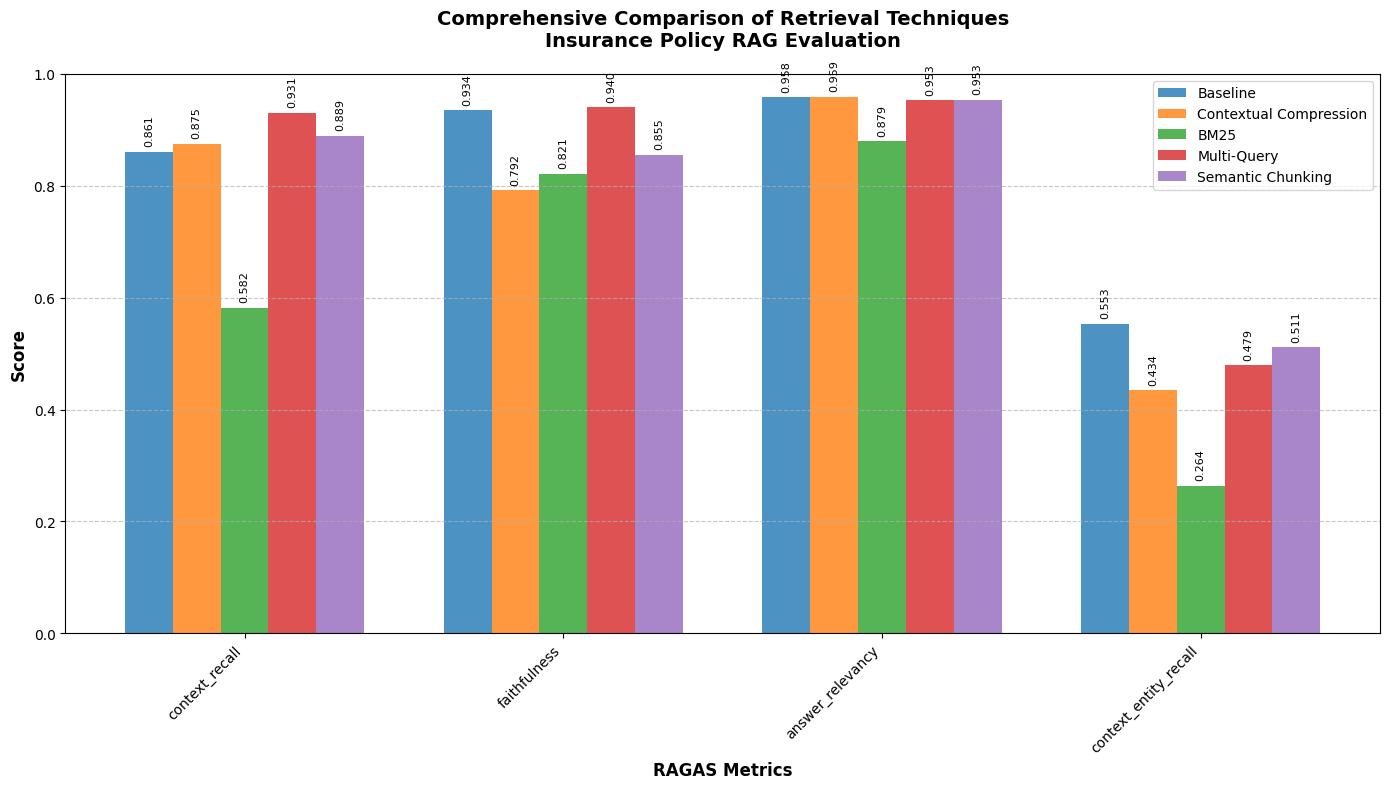

📊 RAGAS Metrics Comparison Summary
                        context_recall  faithfulness  answer_relevancy  \
Baseline                        0.8611        0.9345            0.9582   
Contextual Compression          0.8750        0.7921            0.9586   
BM25                            0.5819        0.8209            0.8794   
Multi-Query                     0.9306        0.9401            0.9529   
Semantic Chunking               0.8889        0.8547            0.9532   

                        context_entity_recall  
Baseline                               0.5531  
Contextual Compression                 0.4342  
BM25                                   0.2642  
Multi-Query                            0.4787  
Semantic Chunking                      0.5113  

🏆 Performance Rankings by Metric:

context_recall:
  1. Multi-Query: 0.9306
  2. Semantic Chunking: 0.8889
  3. Contextual Compression: 0.8750
  4. Baseline: 0.8611
  5. BM25: 0.5819

faithfulness:
  1. Multi-Query: 0.9401
  2. Bas

In [2]:
# Copia y pega todo el contenido de comparison_visualization.py aquí
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 🏗️ XTALLET Notes - All Retriever Results Dictionary
retriever_results = {
    "Baseline": {
        "context_recall": 0.8611,
        "faithfulness": 0.9345,
        "answer_relevancy": 0.9582,
        "context_entity_recall": 0.5531
    },
    "Contextual Compression": {
        "context_recall": 0.8750,
        "faithfulness": 0.7921,
        "answer_relevancy": 0.9586,
        "context_entity_recall": 0.4342
    },
    "BM25": {
        "context_recall": 0.5819,
        "faithfulness": 0.8209,
        "answer_relevancy": 0.8794,
        "context_entity_recall": 0.2642
    },
    "Multi-Query": {
        "context_recall": 0.9306,
        "faithfulness": 0.9401,
        "answer_relevancy": 0.9529,
        "context_entity_recall": 0.4787
    },
    "Semantic Chunking": {
        "context_recall": 0.8889,
        "faithfulness": 0.8547,
        "answer_relevancy": 0.9532,
        "context_entity_recall": 0.5113
    }
}

# 🏗️ XTALLET Notes - Create DataFrame for visualization
df_comparison = pd.DataFrame(retriever_results).T

# 🏗️ XTALLET Notes - Create the comparison chart
fig, ax = plt.subplots(figsize=(14, 8))

# Set up the bar positions
x = np.arange(len(df_comparison.columns))
width = 0.15
multiplier = 0

# Create bars for each retriever
for retriever, scores in df_comparison.iterrows():
    offset = width * multiplier
    rects = ax.bar(x + offset, scores, width, label=retriever, alpha=0.8)
    multiplier += 1

# Customize the chart
ax.set_xlabel('RAGAS Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comprehensive Comparison of Retrieval Techniques\nInsurance Policy RAG Evaluation', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_comparison.columns, rotation=45, ha='right')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
for i, retriever in enumerate(df_comparison.index):
    for j, metric in enumerate(df_comparison.columns):
        value = df_comparison.loc[retriever, metric]
        ax.text(j + i * width, value + 0.01, f'{value:.3f}', 
                ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

# 🏗️ XTALLET Notes - Create a summary table
print("📊 RAGAS Metrics Comparison Summary")
print("=" * 50)
print(df_comparison.round(4))

# 🏗️ XTALLET Notes - Performance ranking
print("\n🏆 Performance Rankings by Metric:")
print("=" * 50)

for metric in df_comparison.columns:
    ranking = df_comparison[metric].sort_values(ascending=False)
    print(f"\n{metric}:")
    for i, (retriever, score) in enumerate(ranking.items(), 1):
        print(f"  {i}. {retriever}: {score:.4f}")

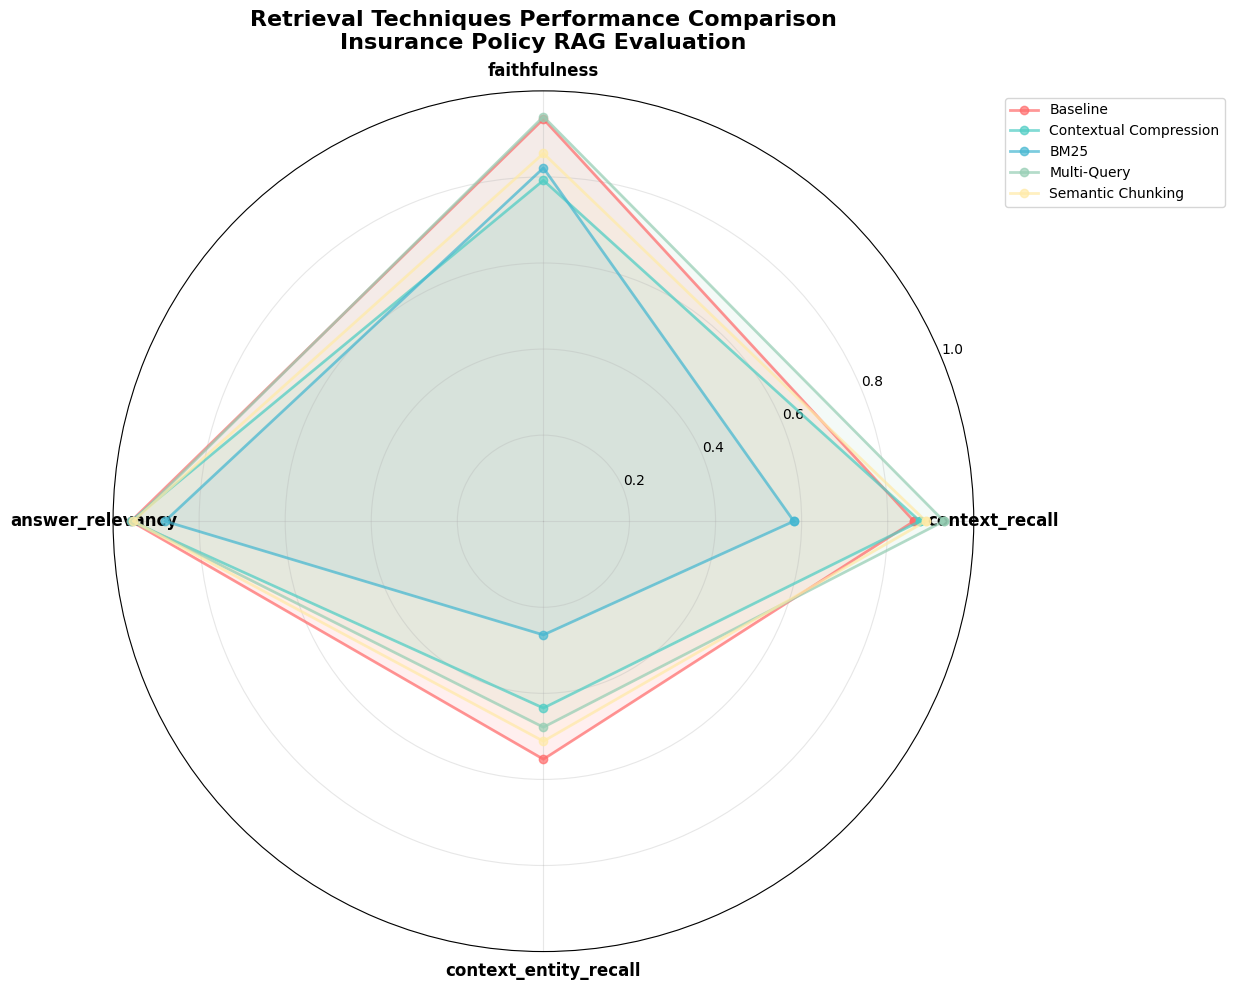

📊 Radar Chart Analysis Summary
Best performers by metric:
------------------------------
context_recall: Multi-Query (0.9306)
faithfulness: Multi-Query (0.9401)
answer_relevancy: Contextual Compression (0.9586)
context_entity_recall: Baseline (0.5531)

🏆 Overall Performance Ranking:
1. Baseline: 0.8267
2. Multi-Query: 0.8256
3. Semantic Chunking: 0.8020
4. Contextual Compression: 0.7650
5. BM25: 0.6366


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 🏗️ XTALLET Notes - All Retriever Results Dictionary
retriever_results = {
    "Baseline": {
        "context_recall": 0.8611,
        "faithfulness": 0.9345,
        "answer_relevancy": 0.9582,
        "context_entity_recall": 0.5531
    },
    "Contextual Compression": {
        "context_recall": 0.8750,
        "faithfulness": 0.7921,
        "answer_relevancy": 0.9586,
        "context_entity_recall": 0.4342
    },
    "BM25": {
        "context_recall": 0.5819,
        "faithfulness": 0.8209,
        "answer_relevancy": 0.8794,
        "context_entity_recall": 0.2642
    },
    "Multi-Query": {
        "context_recall": 0.9306,
        "faithfulness": 0.9401,
        "answer_relevancy": 0.9529,
        "context_entity_recall": 0.4787
    },
    "Semantic Chunking": {
        "context_recall": 0.8889,
        "faithfulness": 0.8547,
        "answer_relevancy": 0.9532,
        "context_entity_recall": 0.5113
    }
}

# 🏗️ XTALLET Notes - Create DataFrame
df_comparison = pd.DataFrame(retriever_results).T

# 🏗️ XTALLET Notes - Radar Chart Setup
categories = df_comparison.columns
N = len(categories)

# Compute angle for each axis
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Complete the circle

# 🏗️ XTALLET Notes - Create the radar chart
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))

# Colors for each retriever
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

# Plot each retriever
for i, (retriever, scores) in enumerate(df_comparison.iterrows()):
    values = scores.values.flatten().tolist()
    values += values[:1]  # Complete the circle
    
    ax.plot(angles, values, 'o-', linewidth=2, label=retriever, color=colors[i], alpha=0.7)
    ax.fill(angles, values, alpha=0.1, color=colors[i])

# 🏗️ XTALLET Notes - Customize the radar chart
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
ax.grid(True, alpha=0.3)

# Add title and legend
plt.title('Retrieval Techniques Performance Comparison\nInsurance Policy RAG Evaluation', 
          fontsize=16, fontweight='bold', pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()

# 🏗️ XTALLET Notes - Performance summary
print("📊 Radar Chart Analysis Summary")
print("=" * 50)
print("Best performers by metric:")
print("-" * 30)

for metric in df_comparison.columns:
    best_retriever = df_comparison[metric].idxmax()
    best_score = df_comparison[metric].max()
    print(f"{metric}: {best_retriever} ({best_score:.4f})")

print("\n🏆 Overall Performance Ranking:")
print("=" * 50)
# Calculate average score for each retriever
avg_scores = df_comparison.mean(axis=1).sort_values(ascending=False)
for i, (retriever, avg_score) in enumerate(avg_scores.items(), 1):
    print(f"{i}. {retriever}: {avg_score:.4f}")

In [ ]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI
from ragas.metrics import (
    LLMContextRecall,
    Faithfulness,
    ResponseRelevancy,
    ContextEntityRecall,
)
from ragas import RunConfig

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))
custom_run_config = RunConfig(timeout=360)

result = evaluate(
    experiment_name='Task5 Eval Naive Retrieval',
    dataset=evaluation_dataset_task5,
    metrics=[
        LLMContextRecall(),
        Faithfulness(),
        ResponseRelevancy(),
        ContextEntityRecall()
    ],
    llm=evaluator_llm,
    run_config=custom_run_config
)
print(result)

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

{'context_recall': 0.8611, 'faithfulness': 0.9345, 'answer_relevancy': 0.9582, 'context_entity_recall': 0.5531}
